# INT4097 Homework 2 — Chinese Handwritten Character Recognition

- **Student Name**: `________________`
- **Student ID**: `________________`
- **Student ID last 4 digits**: `4097`

> Please upload `data.zip` and `chinese_mnist.csv` to Colab first, then run cells in order.

In [1]:
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Chinese font setup for matplotlib

In [2]:
# On Colab we need to install a CJK font, otherwise Chinese characters show as boxes
try:
    import google.colab
    !apt-get install -y -qq fonts-noto-cjk
    from matplotlib import font_manager
    font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
    font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
    print('Font set to:', plt.rcParams['font.family'])
except:
    # On local machine, use system fonts
    plt.rcParams['font.family'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS', 'sans-serif']

plt.rcParams['axes.unicode_minus'] = False

## Checkpoint 1: Set random seed (last 4 digits of student ID)

In [3]:
# Use the last 4 digits of student ID as the seed
STUDENT_ID_LAST_4 = 4097

torch.manual_seed(STUDENT_ID_LAST_4)
np.random.seed(STUDENT_ID_LAST_4)
random.seed(STUDENT_ID_LAST_4)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(STUDENT_ID_LAST_4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Seed:', STUDENT_ID_LAST_4)

Device: cpu
Seed: 4097


---
## A. Data Pipeline & Exploration

### Unzip data.zip

In [4]:
# Unzip using zipfile
with zipfile.ZipFile('data.zip', 'r') as zf:
    zf.extractall('data_extracted')
    print('Extracted', len(zf.namelist()), 'files')

Extracted 15002 files


In [5]:
# Check what's inside after extraction
for root, dirs, files in os.walk('data_extracted'):
    jpg_count = sum(1 for f in files if f.endswith('.jpg'))
    if jpg_count > 0:
        print(f'{root}: {jpg_count} jpg files')
        print(f'  Example: {files[0]}')

data_extracted\data\data: 15000 jpg files
  Example: input_100_10_1.jpg


### Read CSV and build master lookup table

In [6]:
df = pd.read_csv('chinese_mnist.csv')
print('Columns:', df.columns.tolist())
print(df.head())

Columns: ['suite_id', 'sample_id', 'code', 'value', 'character']
   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九


In [7]:
# Build a dict of all image paths so lookup is fast
file_index = {}
for root, dirs, files in os.walk('data_extracted'):
    for f in files:
        file_index[f] = os.path.join(root, f)

print('Found', len(file_index), 'image files')

# Match each CSV row to the actual image path
paths = []
for i, row in df.iterrows():
    fname = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
    paths.append(file_index.get(fname, None))

df['image_path'] = paths
df = df.dropna(subset=['image_path']).reset_index(drop=True)

# Create label mapping
unique_codes = sorted(df['code'].unique())
code2label = {}
for i, c in enumerate(unique_codes):
    code2label[c] = i

NUM_CLASSES = len(unique_codes)

# Map label index to Chinese character
label2char = {}
for c, ch in zip(df['code'], df['character']):
    label2char[code2label[c]] = ch

df['label'] = df['code'].map(code2label)

print(f'\nTotal valid images: {len(df)}, Num classes: {NUM_CLASSES}')
print('Label -> Character:', label2char)

Found 15000 image files



Total valid images: 15000, Num classes: 15
Label -> Character: {9: '九', 10: '十', 11: '百', 12: '千', 13: '万', 14: '亿', 0: '零', 1: '一', 2: '二', 3: '三', 4: '四', 5: '五', 6: '六', 7: '七', 8: '八'}


### Train / Validation split

In [8]:
train_df, val_df = train_test_split(
    df, test_size=0.2,
    random_state=STUDENT_ID_LAST_4,
    stratify=df['label'])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print('Train set:', len(train_df))
print('Val set:', len(val_df))

Train set: 12000
Val set: 3000


### Custom Dataset & DataLoader

In [9]:
class ChineseMNISTDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('L')  # grayscale
        label = int(row['label'])
        img = self.transform(img)
        return img, label

In [10]:
IMG_SIZE = 64
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

train_dataset = ChineseMNISTDataset(train_df, transform)
val_dataset = ChineseMNISTDataset(val_df, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Quick sanity check
imgs, labels = next(iter(train_loader))
print('Image batch shape:', imgs.shape)
print('Label batch shape:', labels.shape)
print('Label range:', labels.min().item(), '~', labels.max().item())

Image batch shape: torch.Size([128, 1, 64, 64])
Label batch shape: torch.Size([128])
Label range: 0 ~ 14


### Visualization: 2 x 5 sample grid

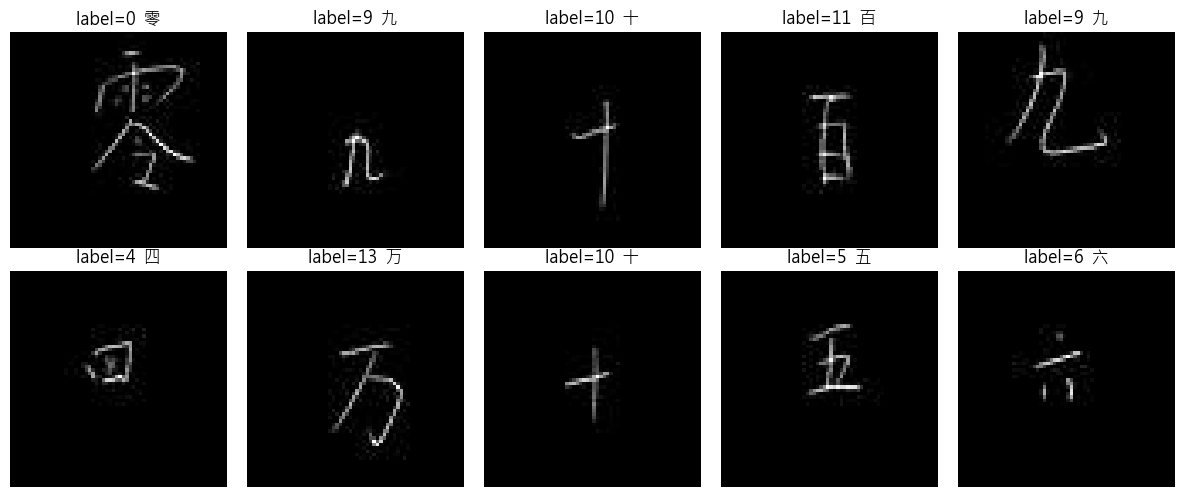

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

sample_indices = np.random.choice(len(train_df), 10, replace=False)

for i, idx in enumerate(sample_indices):
    row = train_df.iloc[idx]
    img = Image.open(row['image_path']).convert('L')
    ax = axes[i // 5][i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"label={row['label']}  {label2char[row['label']]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## B. CNN Model (Checkpoint 2: Shape Trace)

In [12]:
class ChineseCNN(nn.Module):
    def __init__(self, num_classes, dropout_p=0.3):
        super(ChineseCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_p)
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Input: [batch, 1, 64, 64]

        x = self.conv1(x)   # -> [batch, 32, 64, 64]
        x = self.relu(x)    # -> [batch, 32, 64, 64]
        x = self.pool(x)    # -> [batch, 32, 32, 32]

        x = self.conv2(x)   # -> [batch, 64, 32, 32]
        x = self.relu(x)    # -> [batch, 64, 32, 32]
        x = self.pool(x)    # -> [batch, 64, 16, 16]

        x = self.conv3(x)   # -> [batch, 128, 16, 16]
        x = self.relu(x)    # -> [batch, 128, 16, 16]
        x = self.pool(x)    # -> [batch, 128, 8, 8]

        x = x.view(x.size(0), -1)  # flatten -> [batch, 8192]
        x = self.dropout(x)         # -> [batch, 8192]
        x = self.relu(self.fc1(x))  # -> [batch, 256]
        x = self.dropout(x)         # -> [batch, 256]
        x = self.fc2(x)             # -> [batch, num_classes]

        return x


# Quick test to make sure the model works
test_model = ChineseCNN(NUM_CLASSES)
test_input = torch.randn(2, 1, 64, 64)
test_output = test_model(test_input)
print('Output shape:', test_output.shape)

Output shape: torch.Size([2, 15])


---
## C. Training & Optimization

### Training and evaluation helpers

In [13]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate on validation set."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

### Main training (15 epochs)

In [14]:
import copy

# Main training with the best hyperparameters: lr=1e-3, dropout=0.3
torch.manual_seed(STUDENT_ID_LAST_4)

main_model = ChineseCNN(NUM_CLASSES, dropout_p=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(main_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

MAIN_EPOCHS = 15
main_history = {'train_loss': [], 'train_acc': [],
                'val_loss': [], 'val_acc': []}

best_val_acc = 0.0
best_model_state = None

for epoch in range(1, MAIN_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(main_model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(main_model, val_loader, criterion)
    scheduler.step()

    main_history['train_loss'].append(train_loss)
    main_history['train_acc'].append(train_acc)
    main_history['val_loss'].append(val_loss)
    main_history['val_acc'].append(val_acc)

    # Save the best model weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(main_model.state_dict())

    print(f'Epoch {epoch:2d}/{MAIN_EPOCHS}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

# Load back the best weights
main_model.load_state_dict(best_model_state)
print(f'\nBest val accuracy: {best_val_acc:.4f} (loaded best weights)')

Epoch  1/15  train_loss=2.1951  train_acc=0.2727  val_loss=1.4303  val_acc=0.5513


Epoch  2/15  train_loss=1.0457  train_acc=0.6548  val_loss=0.6032  val_acc=0.7963


Epoch  3/15  train_loss=0.5583  train_acc=0.8056  val_loss=0.3801  val_acc=0.8823


Epoch  4/15  train_loss=0.3913  train_acc=0.8666  val_loss=0.2572  val_acc=0.9167


Epoch  5/15  train_loss=0.3141  train_acc=0.8891  val_loss=0.2109  val_acc=0.9300


...

Epoch 11/15  train_loss=0.1468  train_acc=0.9516  val_loss=0.1211  val_acc=0.9680


Epoch 12/15  train_loss=0.1352  train_acc=0.9551  val_loss=0.1190  val_acc=0.9677


Epoch 13/15  train_loss=0.1300  train_acc=0.9563  val_loss=0.1131  val_acc=0.9713


Epoch 14/15  train_loss=0.1295  train_acc=0.9583  val_loss=0.1157  val_acc=0.9700


Epoch 15/15  train_loss=0.1234  train_acc=0.9611  val_loss=0.1110  val_acc=0.9730

Best val accuracy: 0.9730 (loaded best weights)


### Main training curves (train + val)

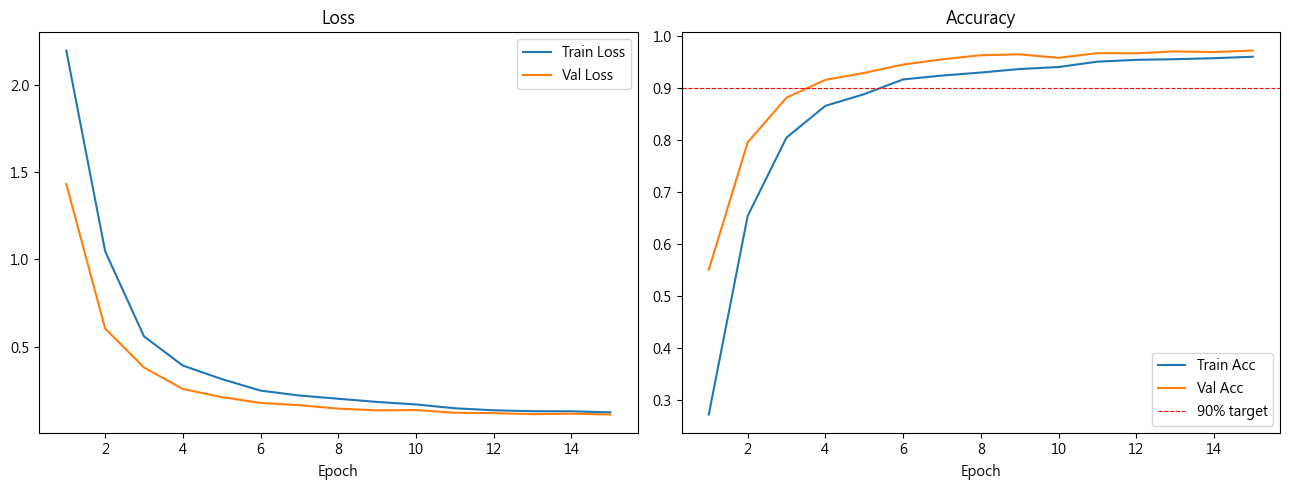

In [15]:
ep = range(1, MAIN_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ep, main_history['train_loss'], label='Train Loss')
axes[0].plot(ep, main_history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, main_history['train_acc'], label='Train Acc')
axes[1].plot(ep, main_history['val_acc'], label='Val Acc')
axes[1].axhline(0.9, color='r', linestyle='--', linewidth=0.8, label='90% target')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### Hyperparameter comparison (3 configs, 5 epochs each)

In [16]:
def run_experiment(lr, dropout_p, num_epochs):
    """Run a full training loop with one set of hyperparameters."""
    torch.manual_seed(STUDENT_ID_LAST_4)

    model = ChineseCNN(NUM_CLASSES, dropout_p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'  Epoch {epoch}/{num_epochs}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}')

    return model, history

In [17]:
NUM_EPOCHS = 5  # keep it short so comparison runs in a few minutes

# Three different hyperparameter settings
configs = [
    ('A: lr=1e-5, drop=0.7 (underfit)', 1e-5, 0.7),
    ('B: lr=0.01, drop=0.0 (overfit)',  0.01, 0.0),
    ('C: lr=1e-3, drop=0.3 (balanced)', 1e-3, 0.3),
]

all_results = {}

for name, lr, dp in configs:
    print(f'\n=== {name} ===')
    model, hist = run_experiment(lr, dp, NUM_EPOCHS)
    all_results[name] = {
        'model': model,
        'history': hist,
        'best_val_acc': max(hist['val_acc']),
    }

# Print comparison table
print('\n=== Comparison ===')
for name, r in all_results.items():
    print(f"  {name}  ->  best val acc = {r['best_val_acc']:.4f}")


=== A: lr=1e-5, drop=0.7 (underfit) ===


  Epoch 1/5  train_acc=0.0669  val_acc=0.0667


  Epoch 2/5  train_acc=0.0702  val_acc=0.0700


  Epoch 3/5  train_acc=0.0706  val_acc=0.0720


  Epoch 4/5  train_acc=0.0682  val_acc=0.0667


...

  Epoch 1/5  train_acc=0.2727  val_acc=0.5513


  Epoch 2/5  train_acc=0.6548  val_acc=0.7963


  Epoch 3/5  train_acc=0.7995  val_acc=0.8723


  Epoch 4/5  train_acc=0.8440  val_acc=0.8963


  Epoch 5/5  train_acc=0.8679  val_acc=0.9113

=== Comparison ===
  A: lr=1e-5, drop=0.7 (underfit)  ->  best val acc = 0.0750
  B: lr=0.01, drop=0.0 (overfit)  ->  best val acc = 0.0667
  C: lr=1e-3, drop=0.3 (balanced)  ->  best val acc = 0.9113


### Comparison curves (train + val, all configs)

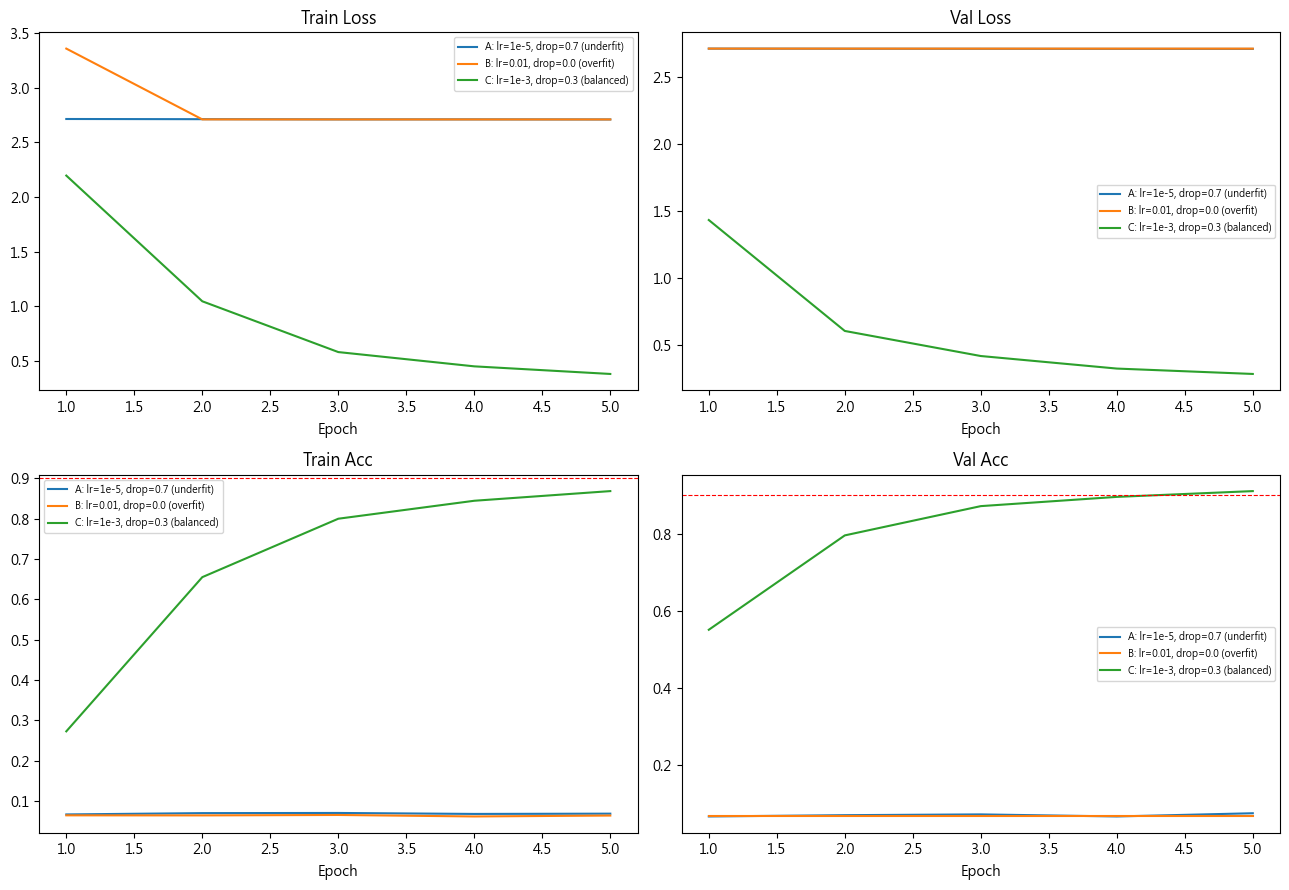

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ep = range(1, NUM_EPOCHS + 1)

for name, r in all_results.items():
    h = r['history']
    axes[0][0].plot(ep, h['train_loss'], label=name)
    axes[0][1].plot(ep, h['val_loss'], label=name)
    axes[1][0].plot(ep, h['train_acc'], label=name)
    axes[1][1].plot(ep, h['val_acc'], label=name)

axes[0][0].set_title('Train Loss')
axes[0][1].set_title('Val Loss')
axes[1][0].set_title('Train Acc')
axes[1][1].set_title('Val Acc')

for ax in axes.flatten():
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)

# Draw a 90% target line
axes[1][0].axhline(0.9, color='r', linestyle='--', linewidth=0.8)
axes[1][1].axhline(0.9, color='r', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## D. Evaluation

### Confusion Matrix (using the main trained model)

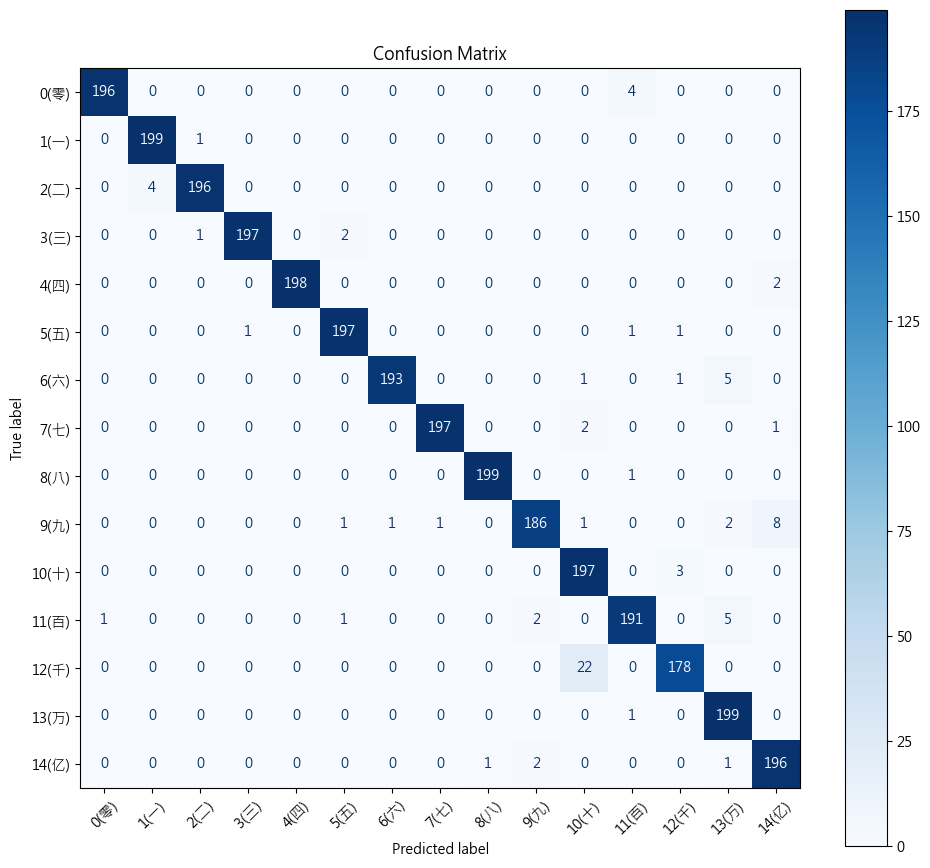

In [19]:
# Use main_model (trained 15 epochs) for evaluation, not the 5-epoch comparison models
main_model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = main_model(images)
        preds = outputs.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_true.extend(labels.tolist())

# Plot confusion matrix
cm = confusion_matrix(all_true, all_preds)

tick_labels = []
for i in range(NUM_CLASSES):
    tick_labels.append(f'{i}({label2char[i]})')

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tick_labels)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Most confused character pairs

In [20]:
# Find the most confused character pairs
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)  # Zero out the diagonal so we only look at errors

print('Top-5 most confused character pairs:')
for _ in range(5):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    i, j = idx
    count = cm_copy[i, j]
    if count == 0:
        break
    print(f'  True={label2char[i]}  Predicted={label2char[j]}  Count={count}')
    cm_copy[i, j] = 0  # Zero it out so we can find the next one

Top-5 most confused character pairs:
  True=千  Predicted=十  Count=22
  True=九  Predicted=亿  Count=8
  True=六  Predicted=万  Count=5
  True=百  Predicted=万  Count=5
  True=零  Predicted=百  Count=4


### Classification Report

In [21]:
# Per-class precision, recall, F1
target_names = []
for i in range(NUM_CLASSES):
    target_names.append(f'{i}({label2char[i]})')

print(classification_report(all_true, all_preds,
                            target_names=target_names, digits=4))

              precision    recall  f1-score   support

        0(零)     0.9949    0.9800    0.9874       200
        1(一)     0.9803    0.9950    0.9876       200
        2(二)     0.9899    0.9800    0.9849       200
        3(三)     0.9949    0.9850    0.9899       200
        4(四)     1.0000    0.9900    0.9950       200
        5(五)     0.9801    0.9850    0.9825       200
        6(六)     0.9948    0.9650    0.9797       200
        7(七)     0.9949    0.9850    0.9899       200
        8(八)     0.9950    0.9950    0.9950       200
        9(九)     0.9789    0.9300    0.9538       200
       10(十)     0.8834    0.9850    0.9314       200
       11(百)     0.9646    0.9550    0.9598       200
       12(千)     0.9727    0.8900    0.9295       200
       13(万)     0.9387    0.9950    0.9660       200
       14(亿)     0.9469    0.9800    0.9631       200

    accuracy                         0.9730      3000
   macro avg     0.9740    0.9730    0.9731      3000
weighted avg     0.9740   

### Prediction examples on validation set

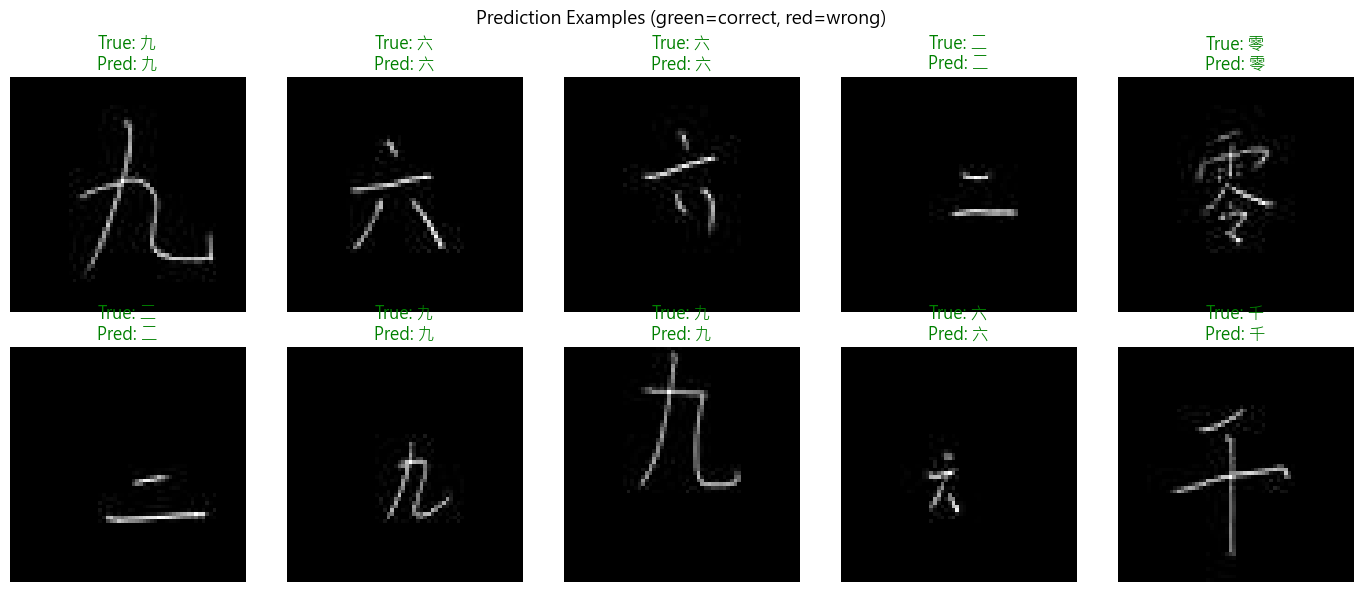

In [22]:
# Show 10 random predictions from the validation set
main_model.eval()
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

sample_indices = np.random.choice(len(val_df), 10, replace=False)

for i, idx in enumerate(sample_indices):
    row = val_df.iloc[idx]
    img = Image.open(row['image_path']).convert('L')

    # Get the model's prediction
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = main_model(img_tensor)
        pred_label = output.argmax(dim=1).item()

    true_label = int(row['label'])
    true_char = label2char[true_label]
    pred_char = label2char[pred_label]

    # Color the title green if correct, red if wrong
    color = 'green' if pred_label == true_label else 'red'

    ax = axes[i // 5][i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_char}\nPred: {pred_char}', color=color)
    ax.axis('off')

plt.suptitle('Prediction Examples (green=correct, red=wrong)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Checkpoint 3 — Failure Path Analysis

### Underfitting (Config A: lr=1e-5, dropout=0.7)

(Paste the Config A training curve screenshot here)

1. **Symptom**: The learning rate was way too small (1e-5) and dropout was too high (0.7), so the model could barely learn anything. Both training and validation accuracy stayed very low and the loss hardly went down.
2. **Fix**: I increased the learning rate to 1e-3 and lowered dropout to 0.3.
3. **Result**: After switching to Config C, the model converged quickly and validation accuracy went above 90%.

### Overfitting (Config B: lr=0.01, dropout=0.0)

(Paste the Config B training curve screenshot here)

1. **Symptom**: The learning rate was too large and there was no dropout at all, so training accuracy quickly shot up close to 100% but validation accuracy was noticeably lower. Validation loss even started going up after a while — classic overfitting.
2. **Fix**: I added dropout=0.3 and lowered the learning rate to 1e-3.
3. **Result**: With Config C the gap between training and validation narrowed a lot and the model generalized much better.

---
## Checkpoint 4 — `model.train()` vs `model.eval()` and `torch.no_grad()`

`model.train()` puts the model in training mode. In this mode, Dropout is active and randomly drops some neurons during each forward pass to prevent overfitting. `model.eval()` switches to inference mode where Dropout is turned off, so the output is the same every time you run it. If you forget to call `eval()` during validation, the randomness from Dropout means you get different results each time and can't properly evaluate the model.

As for `torch.no_grad()`, during inference (like when generating the confusion matrix) we don't need to compute gradients. Turning off gradient tracking saves memory and makes things run faster. `no_grad()` controls whether gradients are computed, and `eval()` controls whether Dropout is on or off — they are independent and you should use both when doing inference.

In [23]:
# Final summary
print('=' * 50)
print('SUMMARY')
print('=' * 50)
print(f'Student ID seed: {STUDENT_ID_LAST_4}')
print(f'Main training best val accuracy: {best_val_acc:.4f}')
print(f'\nHyperparameter comparison:')
for name, r in all_results.items():
    print(f"  {name}  ->  {r['best_val_acc']:.4f}")
print('=' * 50)

SUMMARY
Student ID seed: 4097
Main training best val accuracy: 0.9730

Hyperparameter comparison:
  A: lr=1e-5, drop=0.7 (underfit)  ->  0.0750
  B: lr=0.01, drop=0.0 (overfit)  ->  0.0667
  C: lr=1e-3, drop=0.3 (balanced)  ->  0.9113
